In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset Information ( Phase 2 Only  )



In [ ]:
import os

# Define the paths
paths = [
    "/content/drive/MyDrive/work2/videos/videos_2",
    "/content/drive/MyDrive/work2/Training_Data_Phase_2/Frames",
    "/content/drive/MyDrive/work2/Training_Data_Phase_2/training_audios",
    "/content/drive/MyDrive/work2/Meta_Data/Text_phase2.csv"
]

# Function to calculate size in MB and count files
def get_size_and_count(path):
    total_size = 0
    file_count = 0
    if os.path.isfile(path):
        total_size += os.path.getsize(path)
        file_count += 1
    elif os.path.isdir(path):
        for dirpath, dirnames, filenames in os.walk(path):
            for filename in filenames:
                fp = os.path.join(dirpath, filename)
                total_size += os.path.getsize(fp)
                file_count += 1
    return total_size / (1024 * 1024), file_count  # Convert bytes to MB

# Calculate sizes and counts
total_space = 0
total_files = 0
for path in paths:
    size, count = get_size_and_count(path)
    print(f"Space of files in '{path}': {size:.2f} MB, Number of files: {count}")
    total_space += size
    total_files += count

# Print grand total
print(f"Grand Total Space: {total_space:.2f} MB, Total Number of Files: {total_files}")

Space of files in '/content/drive/MyDrive/work2/videos/videos_2': 6930.83 MB, Number of files: 546
Space of files in '/content/drive/MyDrive/work2/Training_Data_Phase_2/Frames': 1290.57 MB, Number of files: 30560
Space of files in '/content/drive/MyDrive/work2/Training_Data_Phase_2/training_audios': 5200.53 MB, Number of files: 512
Space of files in '/content/drive/MyDrive/work2/Meta_Data/Text_phase2.csv': 0.64 MB, Number of files: 1
Grand Total Space: 13422.58 MB, Total Number of Files: 31619


In [ ]:
import pandas as pd

# Load the CSV file
file_path = "/content/drive/MyDrive/work2/Meta_Data/Text_phase2.csv"
data = pd.read_csv(file_path)

# Calculate number of words, lines, and characters in 'Transcript' column
transcript_column = data['Transcript'].dropna()  # Drop NaN values
total_words = transcript_column.str.split().str.len().sum()
total_lines = transcript_column.count()  # Count of non-null entries
total_characters = transcript_column.str.len().sum()

# Calculate sum of values in 'Length' column
length_sum = data['Length'].sum()

# Print results
print(f"Number of words in 'Transcript': {total_words}")
print(f"Number of lines in 'Transcript': {total_lines}")
print(f"Number of characters in 'Transcript': {total_characters}")
print(f"Sum of values in 'Length' column: {length_sum}")

Number of words in 'Transcript': 82892
Number of lines in 'Transcript': 510
Number of characters in 'Transcript': 351196
Sum of values in 'Length' column: 29436.8


In [ ]:
import pandas as pd

# Replace with your actual file path
file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/urdu-sentiment-corpus-v1.tsv'
# file_path ="/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_2/roman+urdu+sentiment+analysis+dataset+(rusad)/Dataset 11000 Reviews.tsv" Enlish Dataset
try:
    # Read the TSV file into a pandas DataFrame
    df = pd.read_csv(file_path, sep='\t')

    # Print column names
    print("Column Names:")
    print(df.columns)

    # Print the first few rows (adjust the number as needed)
    print("\nFirst 5 rows:")
    print(df.head())

except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except pd.errors.ParserError:
    print(f"Error: Could not parse the file at {file_path}. Check the file format (TSV).")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Column Names:
Index(['Tweet', 'Class'], dtype='object')

First 5 rows:
                                               Tweet Class
0  میں نے ایٹم بم بنایا ھے ۔۔۔۔او بھائی ایٹم بمب ...     P
1  چندے سے انقلاب اور عمران خان وزیر اعظم نہیں بن...     N
2                           ٹویٹر کا خیال کیسے آیا ؟     O
3  سرچ انجن گوگل کے نائب صدر نے فضا میں ، 130,000...     P
4    ابھی تک اسکی لہریں کبھی کبھی آ جاتی ہیں یار :أْ     P


In [ ]:
import pandas as pd

# Replace with your actual file path
file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/urdu-sentiment-corpus-v1.tsv'
# file_path ="/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_2/roman+urdu+sentiment+analysis+dataset+(rusad)/Dataset 11000 Reviews.tsv"  # For English Dataset

try:
    # Read the TSV file into a pandas DataFrame
    df = pd.read_csv(file_path, sep='\t')

    # Print column names
    print("Original Column Names:")
    print(df.columns)

    # Rename columns 'Tweet' to 'Sentence' and 'Class' to 'Label'
    df.rename(columns={'Tweet': 'Sentence', 'Class': 'Label'}, inplace=True)

    # Replace values in the 'Label' column and convert to integer type
    df['Label'] = df['Label'].replace({'P': 1, 'N': 0, 'O': 2}).astype(int)

    # Print the updated column names and first few rows
    print("\nUpdated Column Names:")
    print(df.columns)

    print("\nFirst 5 rows of the updated dataset:")
    print(df.head())

    # Save the updated DataFrame to a new file
    updated_file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/updated_urdu_sentiment_corpus.tsv'
    df.to_csv(updated_file_path, sep='\t', index=False)

    print(f"\nUpdated dataset saved to: {updated_file_path}")

except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except pd.errors.ParserError:
    print(f"Error: Could not parse the file at {file_path}. Check the file format (TSV).")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Original Column Names:
Index(['Tweet', 'Class'], dtype='object')
An unexpected error occurred: Cannot convert non-finite values (NA or inf) to integer


<ipython-input-29-39618955945c>:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Label'] = df['Label'].replace({'P': 1, 'N': 0, 'O': 2}).astype(int)


In [ ]:
import pandas as pd

def select_long_sentences(file_path):
    """
    Selects sentences with more than 10 words from a TSV file.

    Args:
        file_path: The path to the TSV file.

    Returns:
        A pandas DataFrame containing the original sentences and their word count,
        with only sentences that have more than 10 words.
    """
    try:
        df = pd.read_csv(file_path, sep='\t')

        # Display the first few rows of the DataFrame
        print("First few rows of the DataFrame:")
        print(df.head())

        # Ensure 'Sentence' column exists
        if 'Sentence' not in df.columns:
            print("Error: 'Sentence' column not found in the DataFrame.")
            return None

        # Tokenize sentences and count words, handling potential errors
        df['word_count'] = df['Sentence'].apply(lambda x: len(str(x).split()) if isinstance(x, str) else 0)

        # Select sentences with more than 10 words
        long_sentences = df[df['word_count'] > 20]
        return long_sentences

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return None
    except pd.errors.ParserError:
        print(f"Error: Could not parse the file at {file_path}. Check the file format (TSV).")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None


# Example usage:
file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/updated_urdu_sentiment_corpus.tsv'
long_sentences_df = select_long_sentences(file_path)

if long_sentences_df is not None:
    print("Filtered sentences with more than 10 words:")
    print(long_sentences_df.head())


First few rows of the DataFrame:
                                            Sentence  Label
0  میں نے ایٹم بم بنایا ھے ۔۔۔۔او بھائی ایٹم بمب ...      1
1  چندے سے انقلاب اور عمران خان وزیر اعظم نہیں بن...      0
2                           ٹویٹر کا خیال کیسے آیا ؟      2
3  سرچ انجن گوگل کے نائب صدر نے فضا میں ، 130,000...      1
4    ابھی تک اسکی لہریں کبھی کبھی آ جاتی ہیں یار :أْ      1
Filtered sentences with more than 10 words:
                                             Sentence  Label  word_count
0   میں نے ایٹم بم بنایا ھے ۔۔۔۔او بھائی ایٹم بمب ...      1          22
3   سرچ انجن گوگل کے نائب صدر نے فضا میں ، 130,000...      1          24
5    گندی زبان اور گٹر جیسے دماغ والے جاهل جیالے ه...      0          21
8    یہ لفظوں كى شرارت ھے سنبهل کر کچھ بهى لِكهنا ...      1          22
11  سوچا تھا شہباز شریف وہاں سے کام آگے لے کر جائی...      1          33


In [ ]:
# prompt: long_sentences_df.head() save this updated file

# Assuming long_sentences_df is already defined and contains the data
# as shown in the provided code.

if long_sentences_df is not None:
    # Save the updated DataFrame to a new file
    updated_file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/long_sentences.tsv'
    long_sentences_df.to_csv(updated_file_path, sep='\t', index=False)

    print(f"\nDataFrame with long sentences saved to: {updated_file_path}")
else:
    print("DataFrame with long sentences is empty or could not be created.")


DataFrame with long sentences saved to: /content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/long_sentences.tsv


In [ ]:
df.head()

,Sentence,Label
0,میں نے ایٹم بم بنایا ھے ۔۔۔۔او بھائی ایٹم بمب ...,1
1,چندے سے انقلاب اور عمران خان وزیر اعظم نہیں بن...,0
2,ٹویٹر کا خیال کیسے آیا ؟,2
3,"سرچ انجن گوگل کے نائب صدر نے فضا میں ، 130,000...",1
4,ابھی تک اسکی لہریں کبھی کبھی آ جاتی ہیں یار :أْ,1


## Test External Datasets ( No MOre Trainings )



# DS Comparision


# ist Merge files of BOth Phases

In [ ]:
import pandas as pd

# Load the datasets
df_urdu_sentiment = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/urdu-sentiment-corpus-v1.tsv', sep='\t')
df_train_filtered = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train_filtered.tsv', sep='\t')
df_text_phase2 = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Combined.csv')

# Function to calculate total rows, average words, and class distribution
def analyze_dataset(df, text_column, class_column):
    total_rows = len(df)
    # average_words = df[text_column].apply(lambda x: len(str(x).split())).mean()
    class_distribution = df[class_column].value_counts(normalize=True) * 100  # Percentage distribution
    # return total_rows, average_words, class_distribution
    return total_rows, class_distribution
# Analyze each dataset
urdu_sentiment_results = analyze_dataset(df_urdu_sentiment, 'Tweet ', 'Class')
train_filtered_results = analyze_dataset(df_train_filtered, 'TWEETS Data ', 'label')
text_phase2_results = analyze_dataset(df_text_phase2, 'Transcript ', 'Senti')

# Print results
print("Urdu Sentiment Corpus:")
print(f"Total Rows: {urdu_sentiment_results[0]}")
# print(f"Average Words: {urdu_sentiment_results[1]:.2f}")
print("Class Distribution (%):")
print(urdu_sentiment_results[1])

print("\nTrain Filtered Dataset:")
print(f"Total Rows: {train_filtered_results[0]}")
# print(f"Average Words: {train_filtered_results[1]:.2f}")
print("Class Distribution (%):")
print(train_filtered_results[1])

print("\nText Phase 2 Dataset:")
print(f"Total Rows: {text_phase2_results[0]}")
# print(f"Average Words: {text_phase2_results[1]:.2f}")
print("Class Distribution (%):")
print(text_phase2_results[1])



Urdu Sentiment Corpus:
Total Rows: 1000
Class Distribution (%):
Class
N    49.949950
P    48.048048
O     2.002002
Name: proportion, dtype: float64

Train Filtered Dataset:
Total Rows: 126
Class Distribution (%):
label
0    60.317460
1    31.746032
2     7.936508
Name: proportion, dtype: float64

Text Phase 2 Dataset:
Total Rows: 621
Class Distribution (%):
Senti
1    40.418680
0    32.045089
2    27.536232
Name: proportion, dtype: float64


In [ ]:
import pandas as pd

# Load the merged dataset
df_merged_videos = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Merged_Videos.csv')

# Function to calculate total rows and class distribution
def analyze_dataset(df, class_column):
    total_rows = len(df)
    class_distribution = df[class_column].value_counts(normalize=True) * 100  # Percentage distribution
    return total_rows, class_distribution

# Analyze the merged dataset
# Replace 'Class' with the actual column name you want to analyze
merged_videos_results = analyze_dataset(df_merged_videos, 'Senti')

# Print results
print("Merged Videos Dataset:")
print(f"Total Rows: {merged_videos_results[0]}")
print("Class Distribution (%):")
print(merged_videos_results[1])

Merged Videos Dataset:
Total Rows: 398
Class Distribution (%):
Senti
0    35.678392
2    32.914573
1    31.407035
Name: proportion, dtype: float64


In [ ]:
 import pandas as pd

# Load the two CSV files
df_videos_phase1 = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos.csv')
df_videos_phase2 = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Videos_phase2.csv')

# Merge the DataFrames
merged_df = pd.concat([df_videos_phase1, df_videos_phase2], ignore_index=True)

# Save the merged DataFrame to a new CSV file in the same location
merged_df.to_csv('/content/drive/MyDrive/work2/Meta_Data/Merged_Videos.csv', index=False)

In [ ]:
import pandas as pd
# Load the Urdu Sentiment Corpus
df_urdu_sentiment = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/urdu-sentiment-corpus-v1.tsv', sep='\t')
print("Column names in Urdu Sentiment Corpus:", df_urdu_sentiment.columns.tolist())

# Load the Train Filtered dataset
df_train_filtered = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train_filtered.tsv', sep='\t')
print("Column names in Train Filtered dataset:", df_train_filtered.columns.tolist())

# Load the Text Phase 2 dataset
df_text_phase2 = pd.read_csv('/content/drive/MyDrive/work2/Meta_Data/Combined.csv')
print("Column names in Text Phase 2 dataset:", df_text_phase2.columns.tolist())

Column names in Urdu Sentiment Corpus: ['Tweet', 'Class']
Column names in Train Filtered dataset: ['TWEETS Data', 'positiveword1', 'positiveword2', 'negativeword1', 'Nword2', 'nword3', 'NEGtopos', 'postoneg', 'POSadj1', 'posadj2', 'label', 'Word_Count']
Column names in Text Phase 2 dataset: ['Length', 'audio_name', 'Transcript', 'negative_count', 'positive_count', 'negative_positions', 'positive_positions', 'Senti', 'Negative_Frame_Sentiments', 'Positive_Frame_Sentiments']


## External Dataset 1


In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, SequentialSampler, TensorDataset
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import os

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/long_sentences.tsv", sep='\t', encoding='utf-8')

# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model')

# Tokenize and encode the reviews
input_ids = []
attention_masks = []

for review in df['Sentence']:  # Assuming 'Sentence' is the column with text
    encoded_dict = tokenizer.encode_plus(
        review,
        add_special_tokens=True,
        max_length=128,  # Increased max_length for longer text
        truncation=True,
        padding='max_length',  # Consistent padding for all samples
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

# Convert lists to tensors
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

# Load labels
labels = torch.tensor(df['Label'])

# Create TensorDataset and DataLoader
dataset = TensorDataset(input_ids, attention_masks, labels)
dataloader = DataLoader(dataset, batch_size=32, sampler=SequentialSampler(dataset))  # Reduced batch size for better GPU memory management

# Load pre-trained model
model = BertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model',
    num_labels=3,  # Adjust for 3 classes
    output_attentions=False,
    output_hidden_states=False
)

# Evaluation mode
model.eval()

# Move model to GPU if available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# Evaluation loop
all_labels = []
all_preds = []

for batch in dataloader:
    batch = tuple(t.to(device) for t in batch)  # Move batch to device
    inputs = {
        'input_ids': batch[0],
        'attention_mask': batch[1]
    }
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    preds = np.argmax(logits.cpu().numpy(), axis=1)

    all_labels.extend(batch[2].cpu().numpy())
    all_preds.extend(preds)

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Print classification report
class_report = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'])
print('Classification Report:')
print(class_report)

# Save the results to a CSV file
results_df = pd.DataFrame({
    'Model Name': ['BERT Multilingual (Evaluation Only)'],
    'Model Path': ['/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model'],
    'Accuracy': [accuracy],
    'Precision': [np.mean([class_report_dict[label]['precision'] for label in ['neutral', 'positive', 'negative']])],
    'Recall': [np.mean([class_report_dict[label]['recall'] for label in ['neutral', 'positive', 'negative']])],
    'F1 Score': [np.mean([class_report_dict[label]['f1-score'] for label in ['neutral', 'positive', 'negative']])]
})

results_file = '/content/drive/MyDrive/work2/Final/evaluation_results_T1_Final_D1_phase2.csv'

if os.path.exists(results_file):
    existing_df = pd.read_csv(results_file)
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


Accuracy: 39.19%
Classification Report:
              precision    recall  f1-score   support

     neutral       0.58      0.22      0.31       176
    positive       0.54      0.58      0.56       166
    negative       0.02      0.40      0.04         5

    accuracy                           0.39       347
   macro avg       0.38      0.40      0.30       347
weighted avg       0.55      0.39      0.43       347

Results saved to /content/drive/MyDrive/work2/Final/evaluation_results_T1_Final_D1_phase2.csv


In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset, random_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import os
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Load your dataset (only one dataset as per the requirement)
df = pd.read_csv("/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/long_sentences.tsv", sep='\t', encoding='utf-8')

# Tokenizer initialization
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model')

# Tokenize and encode the reviews
input_ids = []
attention_masks = []

for review in df['Sentence']:  # Assuming 'Sentence' is the column with text
    encoded_dict = tokenizer.encode_plus(
        review,
        add_special_tokens=True,
        max_length=64,
        truncation=True,  # Explicitly activate truncation
        padding='max_length',  # Pad to the max_length
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

# Load the labels (assuming 'Label' column has labels)
labels = torch.tensor(df['Label'])

# Split the dataset into training and validation sets
dataset = TensorDataset(input_ids, attention_masks, labels)
train_size = int(0.05 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load pre-trained BERT model for sentiment classification
model = BertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model',
    num_labels=3,  # 3 classes: neutral, positive, negative
    output_attentions=False,
    output_hidden_states=False
)

# Set up optimizer and learning rate scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, eps=1e-8)

# Evaluation loop
model.eval()
all_labels = []
all_preds = []

for batch in val_dataloader:
    inputs = {
        'input_ids': batch[0],
        'attention_mask': batch[1],
        'labels': batch[2]
    }
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    preds = np.argmax(logits.cpu().numpy(), axis=1)

    all_labels.extend(inputs['labels'].cpu().numpy())
    all_preds.extend(preds)

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Generate confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(conf_matrix)

# Print classification report
class_report = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'])
print('Classification Report:')
print(class_report)

# Visualize the results
# Calculate precision, recall, and F1-score
class_report_dict = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'], output_dict=True)
precision = [class_report_dict[label]['precision'] for label in ['neutral', 'positive', 'negative']]
recall = [class_report_dict[label]['recall'] for label in ['neutral', 'positive', 'negative']]
f1_score = [class_report_dict[label]['f1-score'] for label in ['neutral', 'positive', 'negative']]

# Create an interactive confusion matrix
fig = make_subplots(rows=2, cols=2, subplot_titles=['Confusion Matrix', 'Accuracy Bar Chart', 'Precision Bar Chart', 'Recall Bar Chart'])

# Confusion Matrix
trace_heatmap = go.Heatmap(z=conf_matrix, x=['neutral', 'positive', 'negative'], y=['neutral', 'positive', 'negative'], colorscale='Viridis')
fig.add_trace(trace_heatmap, row=1, col=1)

# Accuracy Bar Chart
trace_bar_accuracy = go.Bar(x=['Accuracy'], y=[accuracy * 100], marker=dict(color='blue'))
fig.add_trace(trace_bar_accuracy, row=1, col=2)

# Precision Bar Chart
trace_bar_precision = go.Bar(x=['neutral', 'positive', 'negative'], y=np.round(precision, 2) * 100, marker=dict(color='green'))
fig.add_trace(trace_bar_precision, row=2, col=1)

# Recall Bar Chart
trace_bar_recall = go.Bar(x=['neutral', 'positive', 'negative'], y=np.round(recall, 2) * 100, marker=dict(color='orange'))
fig.add_trace(trace_bar_recall, row=2, col=2)

fig.update_layout(title_text='Confusion Matrix, Accuracy, Precision, and Recall', height=600, width=800)
fig.show()

# Save the results to a CSV file
results_df = pd.DataFrame({
    'Model Name': ['BERT Multilingual'],
    'Model Path': ['/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model'],
    'Accuracy': [accuracy],
    'Precision': [np.mean(precision)],
    'Recall': [np.mean(recall)],
    'F1 Score': [np.mean(f1_score)]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results_T1_Final_D1_phase2.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


Accuracy: 38.79%
Confusion Matrix:
[[34 75 58]
 [25 92 41]
 [ 2  1  2]]
Classification Report:
              precision    recall  f1-score   support

     neutral       0.56      0.20      0.30       167
    positive       0.55      0.58      0.56       158
    negative       0.02      0.40      0.04         5

    accuracy                           0.39       330
   macro avg       0.37      0.40      0.30       330
weighted avg       0.54      0.39      0.42       330



Results saved to /content/drive/MyDrive/work2/Final/evaluation_results_T1_Final_D1_phase2.csv


In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset, random_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import os
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Load your new dataset
df = pd.read_csv("/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/long_sentences.tsv", sep='\t', encoding='utf-8')

# Tokenizer initialization
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model')

# Tokenize and encode the reviews
input_ids = []
attention_masks = []

for review in df['Sentence']:
    encoded_dict = tokenizer.encode_plus(
        review,
        add_special_tokens=True,
        max_length=128,  # Increased max_length for longer sentences
        truncation=True,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

# Load the labels
labels = torch.tensor(df['Label'])

# Split the dataset into training and validation sets
dataset = TensorDataset(input_ids, attention_masks, labels)
train_size = int(0.10 * len(dataset))  # Increase training data size for fine-tuning
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)  # Reduced batch size for stability
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load pre-trained BERT model for sentiment classification
model = BertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model',
    num_labels=3,
    output_attentions=False,
    output_hidden_states=False
)

# Modify dropout rate
model.config.hidden_dropout_prob = 0.1  # Reduced dropout for better stability

# Set up optimizer and learning rate scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, eps=1e-8)  # Reduced learning rate for fine-tuning

# Fine-tuning the model
model.train()
epochs = 3  # Fine-tune for a small number of epochs
for epoch in range(epochs):
    total_loss = 0
    for batch in train_dataloader:
        optimizer.zero_grad()
        inputs = {
            'input_ids': batch[0].to(model.device),
            'attention_mask': batch[1].to(model.device),
            'labels': batch[2].to(model.device)
        }
        outputs = model(**inputs)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch + 1}/{epochs} - Loss: {total_loss:.4f}")

# Evaluation loop
model.eval()
all_labels = []
all_preds = []

for batch in val_dataloader:
    inputs = {
        'input_ids': batch[0],
        'attention_mask': batch[1],
        'labels': batch[2]
    }
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    preds = np.argmax(logits.cpu().numpy(), axis=1)

    all_labels.extend(inputs['labels'].cpu().numpy())
    all_preds.extend(preds)

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Generate confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(conf_matrix)

# Print classification report
class_report = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'])
print('Classification Report:')
print(class_report)

# Save the results to a CSV file
results_df = pd.DataFrame({
    'Model Name': ['BERT Multilingual (Fine-tuned)'],
    'Model Path': ['/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model'],
    'Accuracy': [accuracy],
    'Epochs': [epochs],
    'Learning Rate': [1e-5],
    'Max Length': [128]
})

results_file = '/content/drive/MyDrive/work2/Final/evaluation_results_T1_Final_D1_phase2.csv'

if os.path.exists(results_file):
    existing_df = pd.read_csv(results_file)
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


Epoch 1/3 - Loss: 5.7548
Epoch 2/3 - Loss: 3.6857
Epoch 3/3 - Loss: 1.8919
Accuracy: 55.59%
Confusion Matrix:
[[128  29   0]
 [106  46   0]
 [  3   1   0]]
Classification Report:
              precision    recall  f1-score   support

     neutral       0.54      0.82      0.65       157
    positive       0.61      0.30      0.40       152
    negative       0.00      0.00      0.00         4

    accuracy                           0.56       313
   macro avg       0.38      0.37      0.35       313
weighted avg       0.56      0.56      0.52       313

Results saved to /content/drive/MyDrive/work2/Final/evaluation_results_T1_Final_D1_phase2.csv


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



##BoW for Dataset 1

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning:

Trying to unpickle estimator CountVectorizer from version 1.2.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning:

Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations



Accuracy: 44.95%
Precision: 0.52
Recall: 0.45
F1 Score: 0.32
Confusion Matrix:
[[  9 435  51]
 [  6 435  35]
 [  1  17   1]]


<ipython-input-72-18c9ad40ffd3>:76: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-72-18c9ad40ffd3>:80: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




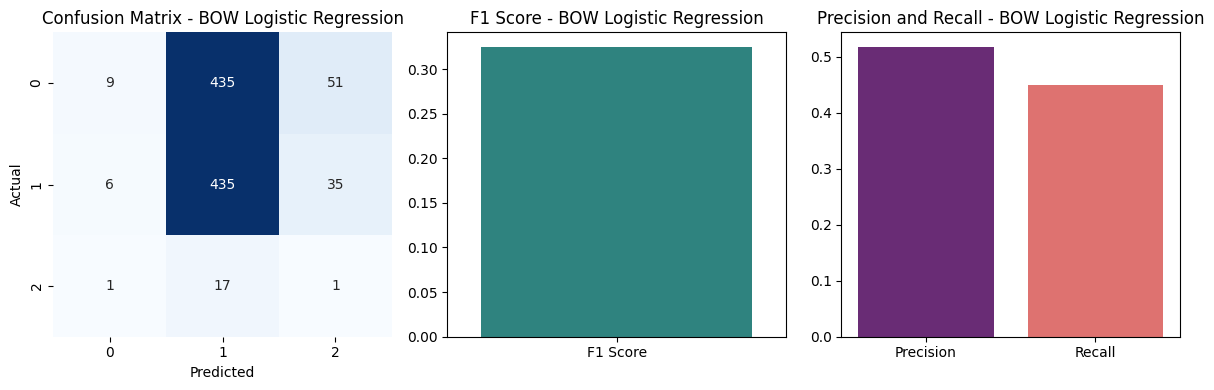

Results saved to /content/drive/MyDrive/work2/Final/evaluation_results_T2__Final_D1_phase2.csv


In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

# Load your dataset (using the updated path)
file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/updated_urdu_sentiment_corpus.tsv'
urdu_doc = pd.read_csv(file_path, sep='\t')

# Function to remove unwanted characters
def removing_unwanted_data(text):
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', '', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\'', ' ', text)
    text = nltk.WordPunctTokenizer().tokenize(text)
    return text

# Apply preprocessing to clean text
urdu_doc['text_cleaned'] = urdu_doc['Sentence'].map(removing_unwanted_data)

# Custom tokenizer function (identity function, you can update it later if needed)
def custom_tokenizer(doc):
    return doc

# Load the saved vectorizer and model (use your model 2 paths)
vectorizer_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_bow_vectorizer.pkl'
model_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_logistic_regression_bow.pkl'

vectorizer = joblib.load(vectorizer_path)
model = joblib.load(model_path)

# Transform the data using the loaded vectorizer
X = vectorizer.transform(urdu_doc['text_cleaned'])
y = urdu_doc['Label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.99, random_state=42)

# Evaluate the loaded model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Visualize the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - BOW Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 2)
sns.barplot(x=['F1 Score'], y=[f1], palette="viridis")
plt.title("F1 Score - BOW Logistic Regression")

plt.subplot(1, 3, 3)
sns.barplot(x=['Precision', 'Recall'], y=[precision, recall], palette="magma")
plt.title("Precision and Recall - BOW Logistic Regression")

plt.tight_layout()
plt.show()

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['BOW Logistic Regression'],
    'Model Path': [model_path],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file (updated to your specified path)
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results_T2__Final_D1_phase2.csv'

# Check if the results file exists and handle the append operation correctly
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    updated_df = pd.concat([existing_df, results_df], ignore_index=True)
    updated_df.to_csv(results_file, index=False)
else:
    results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import os

# Load your dataset (using the updated path)
file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/updated_urdu_sentiment_corpus.tsv'
urdu_doc = pd.read_csv(file_path, sep='\t')

# Function to remove unwanted characters
def removing_unwanted_data(text):
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', '', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\'', ' ', text)
    text = nltk.WordPunctTokenizer().tokenize(text)
    return text

# Apply preprocessing to clean text
urdu_doc['text_cleaned'] = urdu_doc['Sentence'].map(removing_unwanted_data)

# Custom tokenizer function (identity function, you can update it later if needed)
def custom_tokenizer(doc):
    return doc

# Load the saved vectorizer and model (use your model 2 paths)
vectorizer_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_bow_vectorizer.pkl'
model_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_logistic_regression_bow.pkl'

vectorizer = joblib.load(vectorizer_path)
model = joblib.load(model_path)

# Transform the data using the loaded vectorizer
X = vectorizer.transform(urdu_doc['text_cleaned'])
y = urdu_doc['Label']

# Evaluate the loaded model on the entire dataset
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, average='weighted')
recall = recall_score(y, y_pred, average='weighted')
f1 = f1_score(y, y_pred, average='weighted')

# Generate confusion matrix
conf_matrix = confusion_matrix(y, y_pred)

# Generate classification report
class_report = classification_report(y, y_pred)

# Print evaluation metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['BOW Logistic Regression'],
    'Model Path': [model_path],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file (updated to your specified path)
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results_T2__Final_D1_phase2.csv'

# Check if the results file exists and handle the append operation correctly
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    updated_df = pd.concat([existing_df, results_df], ignore_index=True)
    updated_df.to_csv(results_file, index=False)
else:
    results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


Accuracy: 44.90%
Precision: 0.52
Recall: 0.45
F1 Score: 0.32
Confusion Matrix:
[[  9 440  51]
 [  6 439  35]
 [  1  18   1]]
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.02      0.03       500
           1       0.49      0.91      0.64       480
           2       0.01      0.05      0.02        20

    accuracy                           0.45      1000
   macro avg       0.35      0.33      0.23      1000
weighted avg       0.52      0.45      0.32      1000

Results saved to /content/drive/MyDrive/work2/Final/evaluation_results_T2__Final_D1_phase2.csv


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning:

Trying to unpickle estimator CountVectorizer from version 1.2.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning:

Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations



#External Dataset 2 (i.e. D3)


In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset, random_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import os
import plotly.graph_objs as go
from plotly.subplots import make_subplots

# Load your dataset (only one dataset as per the requirement)
df = pd.read_csv("/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train_filtered.tsv", sep='\t', encoding='utf-8')

# Tokenizer initialization
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model')

# Tokenize and encode the reviews
input_ids = []
attention_masks = []

for review in df['TWEETS Data']:  # Assuming 'Sentence' is the column with text
    encoded_dict = tokenizer.encode_plus(
        review,
        add_special_tokens=True,
        max_length=64,
        truncation=True,  # Explicitly activate truncation
        padding='max_length',  # Pad to the max_length
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

# Load the labels (assuming 'Label' column has labels)
labels = torch.tensor(df['label'])

# Split the dataset into training and validation sets
dataset = TensorDataset(input_ids, attention_masks, labels)
train_size = int(0.05 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load pre-trained BERT model for sentiment classification
model = BertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model',
    num_labels=3,  # 3 classes: neutral, positive, negative
    output_attentions=False,
    output_hidden_states=False
)

# Set up optimizer and learning rate scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, eps=1e-8)

# Evaluation loop
model.eval()
all_labels = []
all_preds = []

for batch in val_dataloader:
    inputs = {
        'input_ids': batch[0],
        'attention_mask': batch[1],
        'labels': batch[2]
    }
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    preds = np.argmax(logits.cpu().numpy(), axis=1)

    all_labels.extend(inputs['labels'].cpu().numpy())
    all_preds.extend(preds)

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Generate confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(conf_matrix)

# Generate precision, recall, and F1-score
precision = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'], output_dict=True)['weighted avg']['precision']
recall = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'], output_dict=True)['weighted avg']['recall']
f1 = classification_report(all_labels, all_preds, target_names=['neutral', 'positive', 'negative'], output_dict=True)['weighted avg']['f1-score']

# Save the results to a DataFrame
results_df = pd.DataFrame({
    'Model Name': ['BERT Multilingual'],
    'Model Path': ['/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results_T1_Final_D1_phase2.csv'

# Check if the results file exists
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

# Save the DataFrame to the CSV file
results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")



Accuracy: 30.00%
Confusion Matrix:
[[14  8 50]
 [ 5 14 19]
 [ 0  2  8]]
Results saved to /content/drive/MyDrive/work2/Final/evaluation_results_T1_Final_D1_phase2.csv


In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset, random_split
import os

# Load your dataset (updated path)
file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train_filtered.tsv'
df = pd.read_csv(file_path, sep='\t', encoding='utf-8')

# Tokenizer initialization
tokenizer = BertTokenizer.from_pretrained('/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model')

# Tokenize and encode the reviews
input_ids = []
attention_masks = []

for review in df['TWEETS Data']:
    encoded_dict = tokenizer.encode_plus(
        review,
        add_special_tokens=True,
        max_length=64,
        truncation=True,
        padding='max_length',
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)

# Load the labels
labels = torch.tensor(df['label'])

# Split the dataset into training and validation sets
dataset = TensorDataset(input_ids, attention_masks, labels)
train_size = int(0.99 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoader
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load pre-trained BERT model for sentiment classification
model = BertForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model',
    num_labels=3,
    output_attentions=False,
    output_hidden_states=False
)

# Evaluation loop
model.eval()
all_labels = []
all_preds = []

for batch in val_dataloader:
    inputs = {
        'input_ids': batch[0],
        'attention_mask': batch[1]
    }
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    preds = np.argmax(logits.cpu().numpy(), axis=1)

    all_labels.extend(batch[2].cpu().numpy())
    all_preds.extend(preds)

# Handle case where fewer classes are present in predictions
unique_labels = sorted(set(all_labels))
target_names = ["neutral", "positive", "negative"]
filtered_target_names = [target_names[i] for i in unique_labels]

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Generate confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds, labels=unique_labels)
print('Confusion Matrix:')
print(conf_matrix)

# Generate classification report
class_report = classification_report(all_labels, all_preds, target_names=filtered_target_names)
print('Classification Report:')
print(class_report)

# Save the results to a CSV file
results_df = pd.DataFrame({
    'Model Name': ['BERT Multilingual'],
    'Model Path': ['/content/drive/MyDrive/work2/Final/Text_Work/Text_model_1_BERT_Model'],
    'Accuracy': [accuracy],
    'Precision': [np.mean([precision_score(all_labels, all_preds, average=None)[i] for i in range(len(unique_labels))])],
    'Recall': [np.mean([recall_score(all_labels, all_preds, average=None)[i] for i in range(len(unique_labels))])],
    'F1 Score': [np.mean([f1_score(all_labels, all_preds, average=None)[i] for i in range(len(unique_labels))])]
})

results_file = '/content/drive/MyDrive/work2/Final/evaluation_results_T1_Final_D1_phase2.csv'

if os.path.exists(results_file):
    existing_df = pd.read_csv(results_file)
    results_df = pd.concat([existing_df, results_df], ignore_index=True)

results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


Accuracy: 0.00%
Confusion Matrix:
[[0 0]
 [1 0]]


ValueError: Number of classes, 3, does not match size of target_names, 2. Try specifying the labels parameter

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning:

Trying to unpickle estimator CountVectorizer from version 1.2.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning:

Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

<ipython-input-82-8c115c67cff1>:76: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-82-

Accuracy: 31.20%
Precision: 0.73
Recall: 0.31
F1 Score: 0.19
Confusion Matrix:
[[ 1 58 17]
 [ 0 36  3]
 [ 0  8  2]]


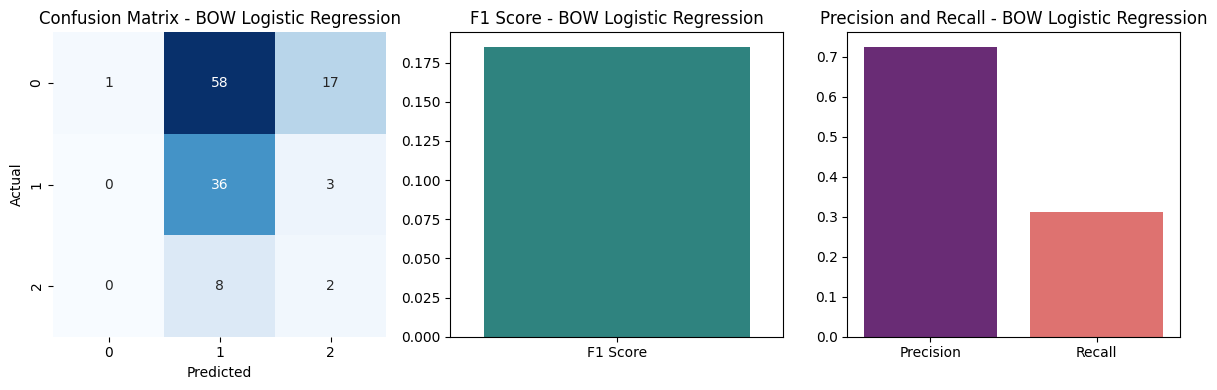

Results saved to /content/drive/MyDrive/work2/Final/evaluation_results_T2__Final_D3_phase2.csv


In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

# Load your dataset (using the updated path)
file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train_filtered.tsv'
urdu_doc = pd.read_csv(file_path, sep='\t')

# Function to remove unwanted characters
def removing_unwanted_data(text):
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', '', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\'', ' ', text)
    text = nltk.WordPunctTokenizer().tokenize(text)
    return text

# Apply preprocessing to clean text
urdu_doc['text_cleaned'] = urdu_doc['TWEETS Data'].map(removing_unwanted_data)

# Custom tokenizer function (identity function, you can update it later if needed)
def custom_tokenizer(doc):
    return doc

# Load the saved vectorizer and model (use your model 2 paths)
vectorizer_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_bow_vectorizer.pkl'
model_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_logistic_regression_bow.pkl'

vectorizer = joblib.load(vectorizer_path)
model = joblib.load(model_path)

# Transform the data using the loaded vectorizer
X = vectorizer.transform(urdu_doc['text_cleaned'])
y = urdu_doc['label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.99, random_state=42)

# Evaluate the loaded model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Visualize the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - BOW Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 3, 2)
sns.barplot(x=['F1 Score'], y=[f1], palette="viridis")
plt.title("F1 Score - BOW Logistic Regression")

plt.subplot(1, 3, 3)
sns.barplot(x=['Precision', 'Recall'], y=[precision, recall], palette="magma")
plt.title("Precision and Recall - BOW Logistic Regression")

plt.tight_layout()
plt.show()

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['BOW Logistic Regression'],
    'Model Path': [model_path],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file (updated to your specified path)
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results_T2__Final_D3_phase2.csv'

# Check if the results file exists and handle the append operation correctly
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    updated_df = pd.concat([existing_df, results_df], ignore_index=True)
    updated_df.to_csv(results_file, index=False)
else:
    results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import os

# Load your dataset (using the updated path)
file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train_filtered.tsv'
urdu_doc = pd.read_csv(file_path, sep='\t')

# Function to remove unwanted characters
def removing_unwanted_data(text):
    text = re.sub(r'https?:\/\/.*[\r\n]*', '', text, flags=re.MULTILINE)
    text = re.sub(r'\<a href', ' ', text)
    text = re.sub(r'&amp;', '', text)
    text = re.sub(r'[_"\-;%()|+&=*%.,!?:#$@\[\]/]', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\'', ' ', text)
    text = nltk.WordPunctTokenizer().tokenize(text)
    return text

# Apply preprocessing to clean text
urdu_doc['text_cleaned'] = urdu_doc['TWEETS Data'].map(removing_unwanted_data)

# Custom tokenizer function (identity function, you can update it later if needed)
def custom_tokenizer(doc):
    return doc

# Load the saved vectorizer and model (use your model 2 paths)
vectorizer_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_bow_vectorizer.pkl'
model_path = '/content/drive/MyDrive/work2/Final/Text_Work/Text_Models_2_and_3/Text_model_2_logistic_regression_bow.pkl'

vectorizer = joblib.load(vectorizer_path)
model = joblib.load(model_path)

# Transform the data using the loaded vectorizer
X = vectorizer.transform(urdu_doc['text_cleaned'])
y = urdu_doc['label']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.99, random_state=42)

# Evaluate the loaded model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

# Generate classification report
unique_labels = sorted(set(y_test))
target_names = [str(label) for label in unique_labels]
class_report = classification_report(y_test, y_pred, target_names=target_names)
print('Classification Report:')
print(class_report)

# Save results in a pandas DataFrame
results_df = pd.DataFrame({
    'Model Name': ['BOW Logistic Regression'],
    'Model Path': [model_path],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1 Score': [f1]
})

# Path to the results file (updated to your specified path)
results_file = '/content/drive/MyDrive/work2/Final/evaluation_results_T2__Final_D3_phase2.csv'

# Check if the results file exists and handle the append operation correctly
if os.path.exists(results_file):
    # If it exists, read the existing data
    existing_df = pd.read_csv(results_file)
    # Append the new results
    updated_df = pd.concat([existing_df, results_df], ignore_index=True)
    updated_df.to_csv(results_file, index=False)
else:
    results_df.to_csv(results_file, index=False)

print(f"Results saved to {results_file}")


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning:

Trying to unpickle estimator CountVectorizer from version 1.2.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning:

Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations



Accuracy: 31.20%
Precision: 0.73
Recall: 0.31
F1 Score: 0.19
Confusion Matrix:
[[ 1 58 17]
 [ 0 36  3]
 [ 0  8  2]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.01      0.03        76
           1       0.35      0.92      0.51        39
           2       0.09      0.20      0.12        10

    accuracy                           0.31       125
   macro avg       0.48      0.38      0.22       125
weighted avg       0.73      0.31      0.19       125

Results saved to /content/drive/MyDrive/work2/Final/evaluation_results_T2__Final_D3_phase2.csv


In [ ]:
#file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/urdu-sentiment-corpus-v1.tsv'
file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/test.xlsx'
# file_path ="/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_2/roman+urdu+sentiment+analysis+dataset+(rusad)/Dataset 11000 Reviews.tsv" Enlish Dataset
try:
    # Read the TSV file into a pandas DataFrame
    #df = pd.read_csv(file_path, sep='\t')
    df = pd.read_excel(file_path)

    # Print column names
    print("Column Names:")
    print(df.columns)

    # Print the first few rows (adjust the number as needed)
    print("\nFirst 5 rows:")
    print(df.head())

except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except pd.errors.ParserError:
    print(f"Error: Could not parse the file at {file_path}. Check the file format.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
df.head()

Column Names:
Index(['  TWEETS Data', 'positive word 1', 'positive word 2',
       'negative word 1', 'N word 2', 'n word 3', 'NEG to pos', 'pos to neg',
       'POS adj 1', 'pos adj 2', 'label'],
      dtype='object')

First 5 rows:
                                         TWEETS Data positive word 1  \
0   میں|UNK نے|P ایٹم|PN بم|NN بنایا|VB ھے۔۔۔۔او|...               1   
1  سرچ|PN انجن|PN گوگل|NN کے|P نائب|ADJ صدر|NN نے...               1   
2  | ابھی|AP تک|P اسکی|G لہریں|NN کبھی|AKP کبھی|A...               0   
3  | گندی|ADJ زبان|NN اور|CC گٹر|NN جیسے|A دماغ|N...               0   
4  قاتل|NN بھی|I تم|PP مقتول|NN بھی|I تم,ظالم|UNK...               0   

  positive word 2 negative word 1 N word 2 n word 3 NEG to pos pos to neg  \
0               0               0        0        0          0         -1   
1               1               0        0        0          0          0   
2               0               0        0        0          0          0   
3               0        

,TWEETS Data,positive word 1,positive word 2,negative word 1,N word 2,n word 3,NEG to pos,pos to neg,POS adj 1,pos adj 2,label
0,میں|UNK نے|P ایٹم|PN بم|NN بنایا|VB ھے۔۔۔۔او|...,1,0,0,0,0,0,-1,0,0,N
1,سرچ|PN انجن|PN گوگل|NN کے|P نائب|ADJ صدر|NN نے...,1,1,0,0,0,0,0,0,0,P
2,| ابھی|AP تک|P اسکی|G لہریں|NN کبھی|AKP کبھی|A...,0,0,0,0,0,0,0,0,0,O
3,| گندی|ADJ زبان|NN اور|CC گٹر|NN جیسے|A دماغ|N...,0,0,-1,-1,-1,1,0,0,0,N
4,"قاتل|NN بھی|I تم|PP مقتول|NN بھی|I تم,ظالم|UNK...",0,0,-1,-1,-1,0,0,0,0,N


In [ ]:
df.head()

,TWEETS Data,positive word 1,positive word 2,negative word 1,N word 2,n word 3,NEG to pos,pos to neg,POS adj 1,pos adj 2,label
0,میں|UNK نے|P ایٹم|PN بم|NN بنایا|VB ھے۔۔۔۔او|...,1,0,0,0,0,0,-1,0,0,N
1,سرچ|PN انجن|PN گوگل|NN کے|P نائب|ADJ صدر|NN نے...,1,1,0,0,0,0,0,0,0,P
2,| ابھی|AP تک|P اسکی|G لہریں|NN کبھی|AKP کبھی|A...,0,0,0,0,0,0,0,0,0,O
3,| گندی|ADJ زبان|NN اور|CC گٹر|NN جیسے|A دماغ|N...,0,0,-1,-1,-1,1,0,0,0,N
4,"قاتل|NN بھی|I تم|PP مقتول|NN بھی|I تم,ظالم|UNK...",0,0,-1,-1,-1,0,0,0,0,N


In [ ]:

# Replace with your actual file path
#file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_1/urdu-sentiment-corpus-v1.tsv'
file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train.xlsx'
# file_path ="/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_2/roman+urdu+sentiment+analysis+dataset+(rusad)/Dataset 11000 Reviews.tsv" Enlish Dataset
try:
    # Read the TSV file into a pandas DataFrame
    #df = pd.read_csv(file_path, sep='\t')
    df = pd.read_excel(file_path)

    # Print column names
    print("Column Names:")
    print(df.columns)

    # Print the first few rows (adjust the number as needed)
    print("\nFirst 5 rows:")
    print(df.head())

except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except pd.errors.ParserError:
    print(f"Error: Could not parse the file at {file_path}. Check the file format.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
df.head()

Column Names:
Index(['  TWEETS Data', 'positiveword1', 'positiveword2', 'negativeword1',
       'Nword2', 'nword3', 'NEGtopos', 'postoneg', 'POSadj1', 'posadj2',
       'label'],
      dtype='object')

First 5 rows:
                                         TWEETS Data  positiveword1  \
0   میں|UNK نے|P ایٹم|PN بم|NN بنایا|VB ھے۔۔۔۔او|...              1   
1  سرچ|PN انجن|PN گوگل|NN کے|P نائب|ADJ صدر|NN نے...              1   
2  | ابھی|AP تک|P اسکی|G لہریں|NN کبھی|AKP کبھی|A...              0   
3  | گندی|ADJ زبان|NN اور|CC گٹر|NN جیسے|A دماغ|N...              0   
4  قاتل|NN بھی|I تم|PP مقتول|NN بھی|I تم,ظالم|UNK...              0   

   positiveword2  negativeword1  Nword2  nword3  NEGtopos  postoneg  POSadj1  \
0              0              0       0       0         0         2        0   
1              1              0       0       0         0         0        0   
2              0              0       0       0         0         0        0   
3              0              2      

,TWEETS Data,positiveword1,positiveword2,negativeword1,Nword2,nword3,NEGtopos,postoneg,POSadj1,posadj2,label
0,میں|UNK نے|P ایٹم|PN بم|NN بنایا|VB ھے۔۔۔۔او|...,1,0,0,0,0,0,2,0,0,0
1,سرچ|PN انجن|PN گوگل|NN کے|P نائب|ADJ صدر|NN نے...,1,1,0,0,0,0,0,0,0,1
2,| ابھی|AP تک|P اسکی|G لہریں|NN کبھی|AKP کبھی|A...,0,0,0,0,0,0,0,0,0,0
3,| گندی|ADJ زبان|NN اور|CC گٹر|NN جیسے|A دماغ|N...,0,0,2,2,2,1,0,0,0,0
4,"قاتل|NN بھی|I تم|PP مقتول|NN بھی|I تم,ظالم|UNK...",0,0,2,2,2,0,0,0,0,0


In [ ]:
df.head()

,TWEETS Data,positiveword1,positiveword2,negativeword1,Nword2,nword3,NEGtopos,postoneg,POSadj1,posadj2,label
0,میں|UNK نے|P ایٹم|PN بم|NN بنایا|VB ھے۔۔۔۔او|...,1,0,0,0,0,0,2,0,0,0
1,سرچ|PN انجن|PN گوگل|NN کے|P نائب|ADJ صدر|NN نے...,1,1,0,0,0,0,0,0,0,1
2,| ابھی|AP تک|P اسکی|G لہریں|NN کبھی|AKP کبھی|A...,0,0,0,0,0,0,0,0,0,0
3,| گندی|ADJ زبان|NN اور|CC گٹر|NN جیسے|A دماغ|N...,0,0,2,2,2,1,0,0,0,0
4,"قاتل|NN بھی|I تم|PP مقتول|NN بھی|I تم,ظالم|UNK...",0,0,2,2,2,0,0,0,0,0


In [ ]:
# prompt: now read this /content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_4/DS_4/urdu_sentences_dataset.csv show coloumn names and rows

from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_4/DS_4/urdu_sentences_dataset.csv'

try:
    df = pd.read_csv(file_path)  # Assuming it's a CSV, adjust if needed

    print("Column Names:")
    print(df.columns)

    print("\nFirst 5 rows:")
    print(df.head())

except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except pd.errors.ParserError:
    print(f"Error: Could not parse the file at {file_path}. Check the file format.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Column Names:
Index(['id', 'text'], dtype='object')

First 5 rows:
                         id                                               text
0  655c852f86396e0f9543416b  بھائی کیا ہو گیا چل کیوں نہیں رہے ہو کیا کرنا ...
1  655c855486396e0f9543416f  ہیلو السلام علیکم اپ کا نام کیا ہے کیا حال ہیں...
2  655c8b06acd6f6b65cc9a590  اچھا اب اس میں ایسا کریں نا یہ اور ہے نا میرا ...
3  655c8b8aacd6f6b65cc9a594  سرچ کریں اس کے اوپر روم پہ اردو لگاتا ہے یہاں ...
4  655d88516e4931707a66f04a  ابھی تم بولو کچھ ہی بول دے بھائی ہیلو السلام ع...


In [ ]:
df.head()

,id,text
0,655c852f86396e0f9543416b,بھائی کیا ہو گیا چل کیوں نہیں رہے ہو کیا کرنا ...
1,655c855486396e0f9543416f,ہیلو السلام علیکم اپ کا نام کیا ہے کیا حال ہیں...
2,655c8b06acd6f6b65cc9a590,اچھا اب اس میں ایسا کریں نا یہ اور ہے نا میرا ...
3,655c8b8aacd6f6b65cc9a594,سرچ کریں اس کے اوپر روم پہ اردو لگاتا ہے یہاں ...
4,655d88516e4931707a66f04a,ابھی تم بولو کچھ ہی بول دے بھائی ہیلو السلام ع...


In [ ]:
import pandas as pd

# Specify the file path
file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train.xlsx'

try:
    # Read the Excel file into a pandas DataFrame
    df = pd.read_excel(file_path)

    # Strip leading/trailing spaces from column names
    df.columns = df.columns.str.strip()

    # Print column names
    print("Column Names after stripping spaces:")
    print(df.columns)

    # Ensure there's a column named 'TWEETS Data'
    if 'TWEETS Data' in df.columns:
        # Add a new column for word count
        df['Word_Count'] = df['TWEETS Data'].astype(str).apply(lambda x: len(x.split()))

        # Print the first few rows of the updated DataFrame
        print("\nUpdated DataFrame:")
        print(df.head())

        # Save the updated DataFrame to a new file
        output_file = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train_updated.xlsx'
        df.to_excel(output_file, index=False)
        print(f"\nUpdated file saved at: {output_file}")
    else:
        print("Error: Column 'TWEETS Data' not found in the dataset. Please check the column name.")

except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except pd.errors.ParserError:
    print(f"Error: Could not parse the file at {file_path}. Check the file format.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Column Names after stripping spaces:
Index(['TWEETS Data', 'positiveword1', 'positiveword2', 'negativeword1',
       'Nword2', 'nword3', 'NEGtopos', 'postoneg', 'POSadj1', 'posadj2',
       'label'],
      dtype='object')

Updated DataFrame:
                                         TWEETS Data  positiveword1  \
0   میں|UNK نے|P ایٹم|PN بم|NN بنایا|VB ھے۔۔۔۔او|...              1   
1  سرچ|PN انجن|PN گوگل|NN کے|P نائب|ADJ صدر|NN نے...              1   
2  | ابھی|AP تک|P اسکی|G لہریں|NN کبھی|AKP کبھی|A...              0   
3  | گندی|ADJ زبان|NN اور|CC گٹر|NN جیسے|A دماغ|N...              0   
4  قاتل|NN بھی|I تم|PP مقتول|NN بھی|I تم,ظالم|UNK...              0   

   positiveword2  negativeword1  Nword2  nword3  NEGtopos  postoneg  POSadj1  \
0              0              0       0       0         0         2        0   
1              1              0       0       0         0         0        0   
2              0              0       0       0         0         0        0   
3          

In [ ]:
df.head(100)

,TWEETS Data,positiveword1,positiveword2,negativeword1,Nword2,nword3,NEGtopos,postoneg,POSadj1,posadj2,label,Word_Count
0,میں|UNK نے|P ایٹم|PN بم|NN بنایا|VB ھے۔۔۔۔او|...,1,0,0,0,0,0,2,0,0,0,21
1,سرچ|PN انجن|PN گوگل|NN کے|P نائب|ADJ صدر|NN نے...,1,1,0,0,0,0,0,0,0,1,23
2,| ابھی|AP تک|P اسکی|G لہریں|NN کبھی|AKP کبھی|A...,0,0,0,0,0,0,0,0,0,0,11
3,| گندی|ADJ زبان|NN اور|CC گٹر|NN جیسے|A دماغ|N...,0,0,2,2,2,1,0,0,0,0,21
4,"قاتل|NN بھی|I تم|PP مقتول|NN بھی|I تم,ظالم|UNK...",0,0,2,2,2,0,0,0,0,0,12
...,...,...,...,...,...,...,...,...,...,...,...,...
95,کراچی.......|UNK سندھ|NN ہائیکورٹ|PN نے|P بحری...,1,0,2,0,0,0,0,1,1,1,20
96,تمام|Q اہل|ADJ اسلام|NN کو|P نیا|ADJ اسلامی|PN...,1,1,0,0,0,0,0,1,1,1,23
97,ریالٹی|PN تو|SC یہ|PP ہے|VB ہمارے|G دونوں|OR ا...,1,1,2,2,0,0,0,1,0,1,30
98,پاکستان|PN کی|P ٹیم|NN میں،احمدشہزاد،|UNK محمد...,0,0,0,0,0,0,0,0,0,2,14


In [ ]:
# prompt: save this into tsv file with only rows where Word_Count value equal to greater then 22

import pandas as pd

# Specify the input and output file paths
input_file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train_updated.xlsx'
output_file_path = '/content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train_filtered.tsv'

try:
    # Read the Excel file
    df = pd.read_excel(input_file_path)

    # Filter rows where 'Word_Count' is greater than 22
    filtered_df = df[df['Word_Count'] >= 22]

    # Save the filtered DataFrame to a TSV file
    filtered_df.to_csv(output_file_path, sep='\t', index=False)

    print(f"Filtered data saved to {output_file_path}")

except FileNotFoundError:
    print(f"Error: Input file not found at {input_file_path}")
except KeyError:
    print(f"Error: 'Word_Count' column not found in the input file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Filtered data saved to /content/drive/MyDrive/work2/Meta_Data/Datasets_Other_Papers/DS_3/train_filtered.tsv
